# Notebook to preprocess hourly biospheric CO2 prior fluxes from JSBACH

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import netCDF4 as nc
import re
from global_land_mask import globe
from scipy.interpolate import griddata
from scipy.ndimage import binary_dilation


import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

# JSBACH 202503 version
 * Lat/lon need to be taken from a separate jsbach.nc -file since jsbach for some reason gives a global grid even though this is a regional run - need to manually adjust
 * 0.125 deg resolution - need to interpolate to 0.1 deg resol
 * the last hour of each year in a separate file: join with the main ds

In [ ]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[-1])
    return year


def create_lsm_like(data):
    lon = data["longitude"].values
    lat = data["latitude"].values
    longrid, latgrid = np.meshgrid(lon,lat)
    lsm = globe.is_land(latgrid, longrid)
    return lsm



def to_highres(ds):
    """Helper to extrapolate JSBACH_202503 data from 0.125 deg resolution to 0.1. Only works with JSBACH_202503 dataset
    as I had to hardcode the new coordinates (was getting annoying rounding errors otherwise)"""
   
    new_lat = np.linspace(35.05, 72.95, 380)
    new_lon = np.linspace(-24.95, 44.95, 700)
    highres_ds = ds.interp({"longitude": new_lon, "latitude": new_lat})
    return highres_ds
    
def naive_interp(ds):
    highres_ds = to_highres(ds)
    lsm = create_lsm_like(highres_ds)
    highres_ds["flux_bio"].values[:,~lsm] = np.nan
    return highres_ds



 

from scipy.interpolate import griddata


def interpolate_flux(flux, lat, lon, max_distance=2, method="linear"):
    """
    Performs interpolation on a single time step, extending land flux values to the ocean.
    
    Parameters:
    - flux: 2D numpy array (latitude x longitude) with land flux values (NaN in ocean).
    - lat: 1D numpy array of latitude values.
    - lon: 1D numpy array of longitude values.
    - max_distance: Maximum pixel distance to extend values into the ocean.
    - method: Interpolation method ('linear', 'nearest', or 'cubic').
    
    Returns:
    - Interpolated 2D numpy array.
    """
    # Create a 2D latitude-longitude grid
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Determine ocean mask using global_land_mask (True for ocean, False for land)
    ocean_mask = globe.is_ocean(lat_grid, lon_grid)

    # Identify NaN values in the flux dataset (missing ocean values)
    missing_mask = np.isnan(flux)

    # Identify land values (valid non-NaN flux)
    land_mask = ~missing_mask

    # Expand land mask using binary dilation (extend land influence)
    extended_land_mask = binary_dilation(land_mask, iterations=max_distance)

    # Identify ocean pixels close to land for interpolation
    interpolatable_ocean_mask = extended_land_mask & ocean_mask & missing_mask

    # Flatten arrays for interpolation
    lat_flat, lon_flat = lat_grid.ravel(), lon_grid.ravel()
    flux_flat = flux.ravel()

    # Prepare points for interpolation
    points = np.column_stack((lat_flat, lon_flat))

    # Select valid land points
    valid_mask = land_mask.ravel()
    valid_points = points[valid_mask]
    valid_values = flux_flat[valid_mask]

    # Select ocean points that need interpolation
    interp_mask = interpolatable_ocean_mask.ravel()
    interp_points = points[interp_mask]

    # Perform interpolation
    interpolated_values = griddata(valid_points, valid_values, interp_points, method=method, fill_value=np.nan)

    # Create a copy of the flux data and update interpolated values
    new_flux = flux.copy()
    new_flux.ravel()[interp_mask] = interpolated_values  # Assign interpolated values

    return new_flux


def extend_flux_to_ocean(dataset, variable_name, max_distance=2, method='linear'):
    """
    Interpolates CO₂ flux values at each time step, extending land values into the ocean.

    Parameters:
    - dataset: xarray.Dataset containing the variable to interpolate.
    - variable_name: str, name of the variable (e.g., 'co2_flux').
    - max_distance: int, maximum number of pixels to extend values into the ocean.
    - method: str, interpolation method ('linear', 'nearest', 'cubic').

    Returns:
    - new_dataset: xarray.Dataset with interpolated values at each time step.
    """
    # Create a deep copy of the dataset to avoid modifying the original
    new_dataset = dataset.copy(deep=True)

    # Extract latitude and longitude
    lat = new_dataset['latitude'].values
    lon = new_dataset['longitude'].values

    # Apply interpolation function along the time dimension using xarray.apply_ufunc()
    new_flux = xr.apply_ufunc(
        interpolate_flux,
        new_dataset[variable_name],
        input_core_dims=[["latitude", "longitude"]],
        output_core_dims=[["latitude", "longitude"]],
        vectorize=True,  # Apply the function to each time step
        dask="parallelized",  # Enable parallel computation if using Dask
        kwargs={"lat": lat, "lon": lon, "max_distance": max_distance, "method": method},
    )

    # Update the variable in the new dataset
    new_dataset[variable_name] = new_flux

    return new_dataset  # Return the new dataset without modifying the original


    


## Middle step: combine data by year and attach correct lat-lon coordinates

In [ ]:
DATA_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/rawdata/"
OUT_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/res_0.125_combined_by_year/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.nc')]


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)


#get the correct coordinates from jsbach.nc file
gridfile = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/jsbach.nc", decode_cf=False)
lats = gridfile.lat.values
lons = gridfile.lon.values
gridfile.close()

#combine datasets from the same year into one dataset
for year in range(2009,2024):
    print(f"processing year {year}")
    fnames_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(fnames_1year)==2
    files_1year = [xr.open_dataset(f) for f in fnames_1year]
    ds_1year= xr.concat(files_1year,dim="time")
    
    #assign the correct coordinates
    ds_1year = ds_1year.assign_coords(lon=(lons), lat=(lats))

    #rename variables to match CIF standard
    rename_map = {
        "CO2_flux_net" : "flux_bio",
        "lat": "latitude",
        "lon": "longitude",
    }

    ds_1year = ds_1year.rename(rename_map)

    ds_1year.attrs.update({"description": "JSBACH 202503 CO2 net flux to atmosphere with corrected grid",
                        "units": "mol(CO2) m-2(grid box) s-1"})

    outname = f"CO2_bio_regional_{str(year)}.nc"
    ds_1year.to_netcdf(os.path.join(OUT_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    for ds in files_1year:
        ds.close()




processing year 2009
processing year 2010
processing year 2011
processing year 2012
processing year 2013
processing year 2014
processing year 2015
processing year 2016
processing year 2017
processing year 2018
processing year 2019
processing year 2020
processing year 2021
processing year 2022
processing year 2023


## Interpolate from 0.125 to 0.1 deg resolution

In [17]:
DATA_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/res_0.125_combined_by_year/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.nc')]
fnames.sort()
for fname in fnames[:1]:
    year = extract_year(fname)
    ds = xr.open_dataset(fname)
    ds_small = ds.isel({"time": [0,1]})
    ds.close()
    padded_ds = extend_flux_to_ocean(ds_small, "flux_bio")
    

In [27]:

highres = naive_interp(padded_ds)

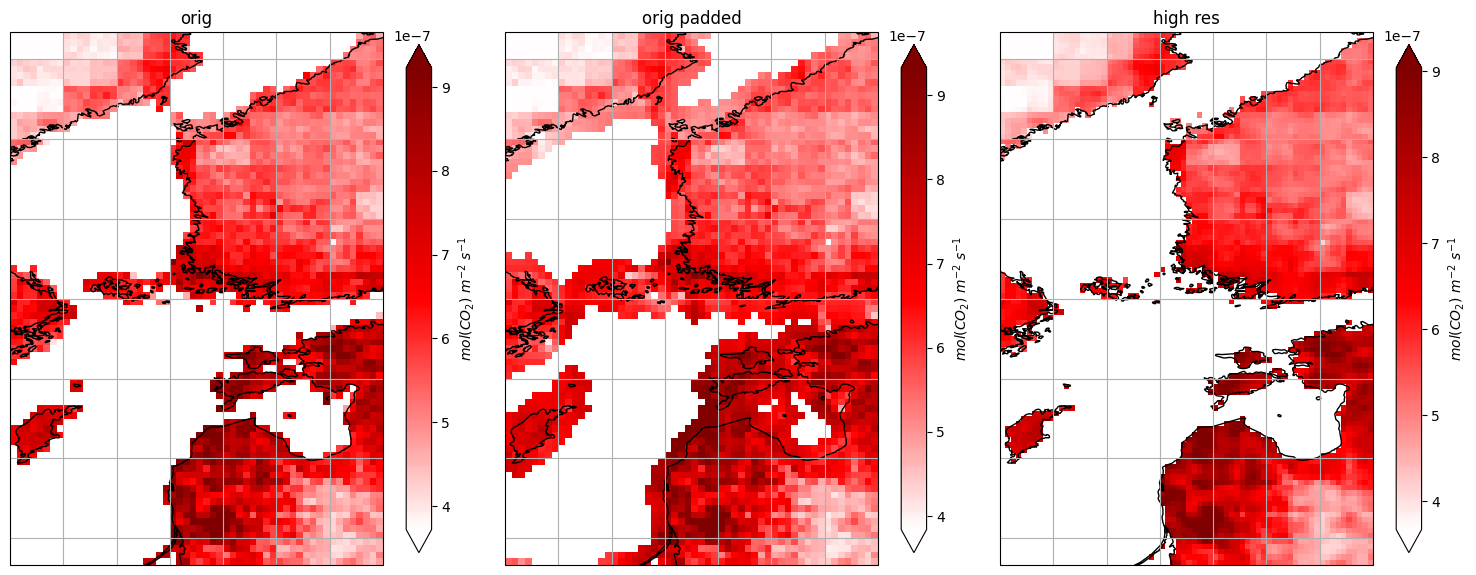

In [31]:
from truncate_colormap import truncate_colormap

titles = ["orig","orig padded", "high res"]
datas = [ds_small, padded_ds, highres]
subsets = []
aoi_subset = [18, 25, 55, 65] 
for data in datas:
    subset = select_area(aoi_subset, data)
    subset = subset["flux_bio"][0,:,:]
    subsets.append(subset)




cbar_label= "$mol(CO_2)$ $m^{-2}$ $s^{-1}$"
cbar_shrink = 0.4
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
#cmap = mpl.colormaps["seismic"]

fig, axs = plt.subplots(1,3, figsize=(15,13), subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = subsets[i]
    
    data.plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    ax.gridlines()#draw_labels=True)
    ax.set_title(titles[i])
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

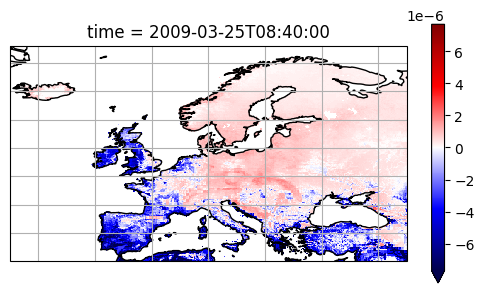

In [ ]:
import matplotlib.pyplot as plt


toplot= ds_1year.flux_bio[2000,:, :]

cbar_label = ""#"emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "flux_bio"
cbar_shrink = 0.7
cmap = mpl.colormaps["seismic"]
#suptitle="Average yearly CO$_2$ fire emissions $2018-2022$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

toplot.plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines()


# Examine the created files

In [ ]:
OUT_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/bio_prior_domain_-12_35_35_72/"
fnames_processed = [os.path.join(OUT_PATH, f) for f in os.listdir(OUT_PATH)]
ds_1year = xr.open_dataset(fnames_processed[5])



#flux[~np.isnan(flux)].shape


FileNotFoundError: [Errno 2] No such file or directory: '/home/pietaril/Documents/data/JSBACH_CO2/bio_prior_domain_-12_35_35_72/'

# Convert to g/m2/yr for Tuula's plots

In [7]:
def hourly_kgm2hr_to_gm2yr(ds):
    """Unit conversion for hourly time resolution data from unit kg/m2/hr to g/m2/yr"""

    #hourly to yearly
    out = ds["emi_bio"].sum(dim="time")
    #kg to g
    out = out*1000
    #pick the first timestamp as the time axis value to represent the year
    time = ds["time"].values[0]
    out = out.to_dataset()
    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out


In [8]:
fnames_processed = [os.path.join(OUT_PATH, f) for f in os.listdir(OUT_PATH)]


#compute and save to file g/m2/yr grids
for fname in fnames_processed:
    year = fname[-7:-3]
    ds_in = xr.open_dataset(fname)
    ds_out = hourly_kgm2hr_to_gm2yr(ds_in)
     # Save the result to a new NetCDF file
    
    ds_out.attrs.update({"description": "Gridded yearly biospheric CO2 fluxes computed from hourly NEE",
                            "units": "g m-2 yr-1"})

    fname_out = f"yearly_NEE_{year}.nc"
    YEARLY_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/g_m2_yr_grids/"
    ds_out.to_netcdf(os.path.join(YEARLY_PATH, fname_out))

    ds_in.close() 



# Compute domain totals for Finland

In [ ]:
from areagrid import areagrid

def g_per_m2_per_yr_to_Mt_per_yr(ds, var):
    
    lat = ds["latitude"].values
    lon = ds["longitude"].values


    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    # pointwise multiplication by area
    totals = ds[var] * grid_of_areas


    domain_tot = totals.sum(dim=("latitude", "longitude"))

    #g to Mt
    domain_tot = domain_tot*1e-12

    return domain_tot


def get_fin_mask(data_to_be_masked):

    """Helper function to get Finland mask with the same dimensionality
    as the data to be masked (when the data has the aoi used in this function. Could
    later improve this to read the aoi also from the input data)"""

    MASK_PATH = "/home/pietaril/Documents/data/masks/country_masks/eez_01x01.nc4"
    ds_mask = xr.open_dataset(MASK_PATH)
    msk = ds_mask.Band1
    ds_mask.close()

    #limit the mask first to the same domain where the saved g/m2/yr values are
    latmin = data_to_be_masked["latitude"].values.min()-0.05
    latmax = data_to_be_masked["latitude"].values.max()+0.05
    lonmin = data_to_be_masked["longitude"].values.min()-0.05
    lonmax = data_to_be_masked["longitude"].values.max()+0.05
    aoi = [lonmin, lonmax, latmin, latmax]
    msk = select_area(aoi,msk)

    #Finland = 83
    msk_fin = msk==83

    #rename dimensions to match the ones in the data
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        }
    msk_fin = msk_fin.rename(rename_map)

    #expand time dimension to match the data
    msk_fin_expanded = msk_fin.expand_dims(time=data_to_be_masked.time)

    return msk_fin_expanded

In [ ]:
fnames_yearly = [os.path.join(YEARLY_PATH, f) for f in os.listdir(YEARLY_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

#expand the mask to match the dimensions of the data
msk_fin_expanded = get_fin_mask(ds_allyears)
fin_gm2yr = ds_allyears.where(msk_fin_expanded.values, drop=False)
fin_tot = g_per_m2_per_yr_to_Mt_per_yr(fin_gm2yr)

# Plot

In [24]:
fnames_yearly = [os.path.join(YEARLY_PATH, f) for f in os.listdir(YEARLY_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

def plot_yearly_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.8

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:4]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

    # Draw the plot
    plt.draw()

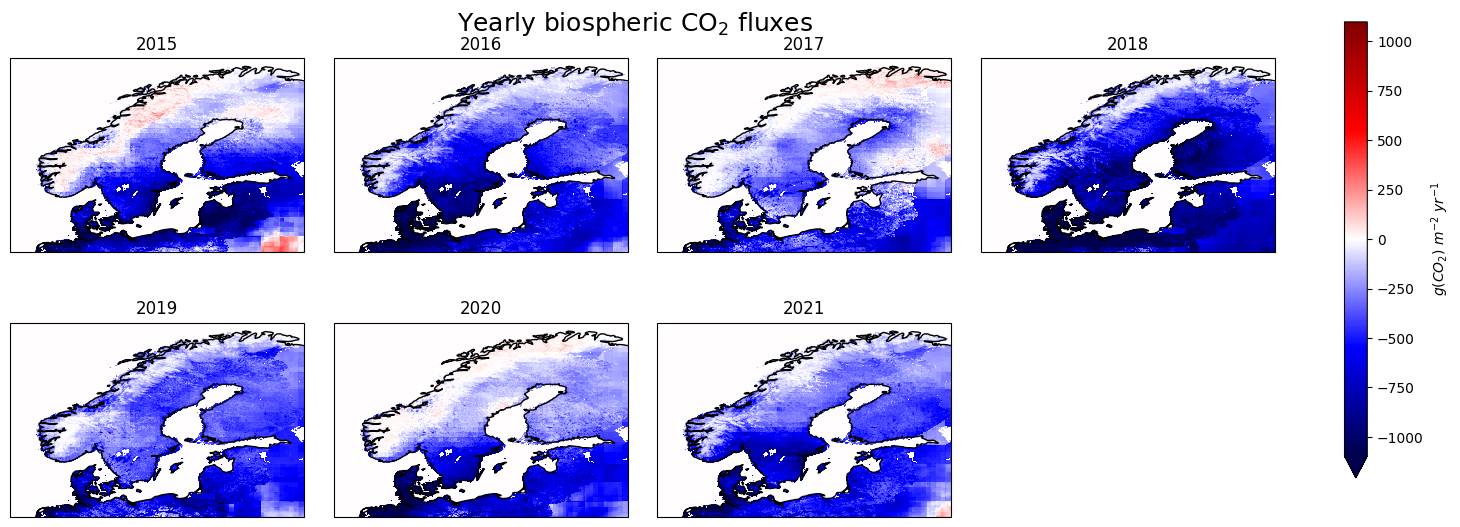

In [26]:

cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_bio"
ncols = 4
cmap =mpl.colormaps["seismic"]
suptitle="Yearly biospheric CO$_2$ fluxes"

aoi_scand = [2, 31.5, 52.5, 72]

scand = select_area(aoi_scand, ds_allyears)

plot_yearly_fluxes(scand, variable, ncols, cmap, cbar_label, suptitle)
figpath = "/home/pietaril/Documents/plots/JSBACH/"
figname = "scand_yearly_bio_CO2_fluxes.png"
plt.savefig(figpath+figname)
plt.draw()

In [30]:
#compute the mean for the chosen range of years
years = range(2017, 2022)

scand_17_21 = scand.isel(time=scand.time.dt.year.isin(years))
scand_ave = scand_17_21.mean(dim="time")
scand_ave

<xarray.Dataset>
Dimensions:    (latitude: 195, longitude: 295)
Coordinates:
  * latitude   (latitude) float32 52.55 52.65 52.75 52.85 ... 71.75 71.85 71.95
  * longitude  (longitude) float32 2.05 2.15 2.25 2.35 ... 31.25 31.35 31.45
Data variables:
    emi_bio    (latitude, longitude) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

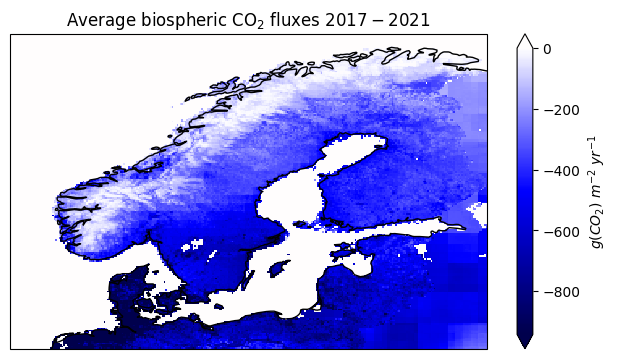

In [37]:
from truncate_colormap import truncate_colormap

cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_bio"
cbar_shrink = 0.7
cmap = truncate_colormap(mpl.colormaps["seismic"], maxval=0.5)
suptitle="Average biospheric CO$_2$ fluxes $2017-2021$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

scand_ave["emi_bio"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/JSBACH/"
figname = f"JSBACH_scandinavia_mean_CO2_flux_2017_2021.png"
plt.savefig(figpath+figname)
plt.draw()